In [12]:
! export CUDNN_DETERMINISTIC=1
! export XLA_FLAGS='--xla_gpu_deterministic_ops=true --xla_gpu_autotune_level=0' 
! export TF_DETERMINISTIC_OPS=1
! export XLA_PYTHON_CLIENT_PREALLOCATE=false

/home/clown2/anaconda3/envs/jax_lnn_312/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [13]:
import jax
import jax.numpy as jnp
import numpy as np
from jax.experimental.ode import odeint
import matplotlib.pyplot as plt
from functools import partial # reduces arguments to function by making some subset implicit

from jax.example_libraries import stax
from jax.example_libraries import optimizers

# visualization
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
# from moviepy.video.io.ImageSequenceClip import ImageSequenceClip
from functools import partial
# import proglog
# from PIL import Image

from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)

gpu


In [14]:
def normalize_dp(state):
  # wrap generalized coordinates to [-pi, pi]
  return jnp.concatenate([
    (state[0] * 0)[None],
    (state[1])[None],
    (state[2] * 0)[None],
    state[3:]],
    )

def rk4_step(f, x, t, h):
  # one step of runge-kutta integration
  k1 = h * f(x, t)
  k2 = h * f(x + k1/2, t + h/2)
  k3 = h * f(x + k2/2, t + h/2)
  k4 = h * f(x + k3, t + h)
  return x + 1/6 * (k1 + 2 * k2 + 2 * k3 + k4)

In [15]:
import pickle 

with open('block_simulation_sample.pkl', 'rb') as f:
    block_data = pickle.load(f)

pos = jnp.array(block_data[:,:3])
vel = jnp.array(block_data[:,3:6])
forces = jnp.array(block_data[:,6:9])
acc = jnp.array(block_data[:,9:12])

train_test_split = int(0.8 * pos.shape[0])

x_train = jnp.concatenate([pos[:train_test_split], vel[:train_test_split]], axis=1)
xt_train = jnp.concatenate([vel[:train_test_split], acc[:train_test_split]], axis=1)
f_train = forces[:train_test_split]

x_test = jnp.concatenate([pos[train_test_split:], vel[train_test_split:]], axis=1)
xt_test = jnp.concatenate([vel[train_test_split:], acc[train_test_split:]], axis=1)
f_test = forces[train_test_split:]


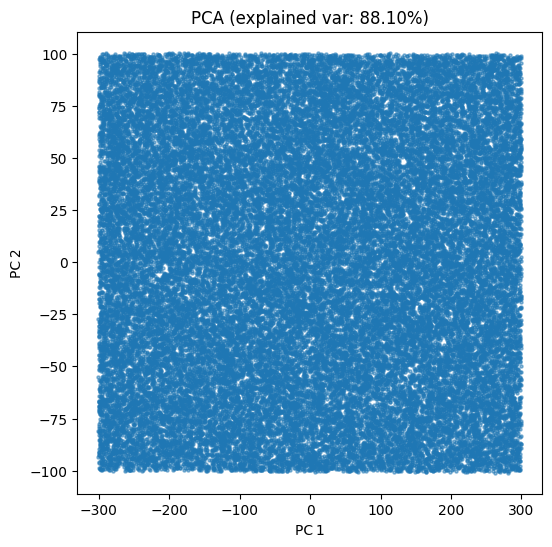

In [16]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# assume pos, vel, acc, forces are each (N,3) NumPy arrays
data = np.hstack([pos, vel, acc, forces])   # shape (N, 12)

# 1) fit PCA
pca = PCA(n_components=2)
proj = pca.fit_transform(data)              # (N, 2)

# 2) plot
plt.figure(figsize=(6,6))
plt.scatter(proj[:,0], proj[:,1], s=5, alpha=0.5)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title(f'PCA (explained var: {pca.explained_variance_ratio_[:2].sum():.2%})')
plt.show()

In [5]:
# replace the lagrangian with a parameteric model
def learned_lagrangian(params):
  def lagrangian(q, q_t):
    assert q.shape == (3,)
    inp = normalize_dp(jnp.concatenate([q, q_t]))
    return jnp.squeeze(nn_forward_fn(params, inp), axis=-1)
  return lagrangian

@partial(jax.jit, static_argnums=())
def batch_dynamics(params, states, forces):
    def single_eom(x, f):
        q, q_t = jnp.split(x, 2)
        L = learned_lagrangian(params)
        # use jacfwd+grad instead of full hessian for a 3×3 mass matrix
        M   = jax.jacfwd(jax.grad(L, argnums=1), argnums=1)(q, q_t)
        M_reg = M + 1e-5 * jnp.eye(M.shape[-1])   # add small diagonal
        dLdq = jax.grad(L, argnums=0)(q, q_t)
        C   = jax.jacfwd(jax.jacobian(L, argnums=1), argnums=0)(q, q_t)
        q_tt = jnp.linalg.solve(M_reg, dLdq + f - C @ q_t)
        return jnp.concatenate([q_t, q_tt])
    return jax.vmap(single_eom)(states, forces)

@jax.jit
def loss(params, batch):
    states, targets, forces = batch
    preds = batch_dynamics(params, states, forces)
    return jnp.mean((preds - targets) ** 2)

# @jax.jit
# def loss(params, batch):
#     states, targets, forces = batch
#     preds = batch_dynamics(params, states, forces)
#     # L∞ = max |preds − targets|
#     return jnp.max(jnp.abs(preds - targets))

# @jax.jit
# def loss(params, batch):
#     states, targets, forces = batch
#     preds = batch_dynamics(params, states, forces)
#     # compute |error| per element, then max over last axis (features),
#     # then mean over batch axis
#     per_sample_max = jnp.max(jnp.abs(preds - targets), axis=tuple(range(1, preds.ndim)))
#     return jnp.mean(per_sample_max)

init_random_params, nn_forward_fn = stax.serial(
    stax.Dense(128),
    stax.Softplus,
    stax.Dense(128),
    stax.Softplus,
    stax.Dense(1),
)

In [6]:
x_train = jax.vmap(normalize_dp)(x_train)
x_test = jax.vmap(normalize_dp)(x_test)


In [7]:
import optax
import jax.lax as lax
from jax import debug

key = jax.random.PRNGKey(0)
key, subkey = jax.random.split(key)
# _, init_params = init_random_params(subkey, (-1, 9))
_, init_params = init_random_params(subkey, (-1, 6))

# numbers in comments denote stephan's settings
batch_size = 256
test_every = 1000
num_batches = 1500

num_train = x_train.shape[0]

train_losses = []
test_losses = []
gns = []
lrs = []

# total_steps = batch_size * num_batches
total_steps = 5e5

lr_schedule = optax.cosine_decay_schedule(
  init_value=1e-3, decay_steps=total_steps, alpha=1e-5
)

optimizer = optax.chain(
  optax.clip_by_global_norm(5),
  optax.adamw(learning_rate=lr_schedule, weight_decay=1e-2),
)

opt_state = optimizer.init(init_params)
params = init_params

@jax.jit
def train_step(params, opt_state, batch, step):
    grads = jax.grad(loss)(params, batch)
    gn = optax.global_norm(grads)
    lr = lr_schedule(step)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, gn, lr

def scan_step(carry, _):
    params, opt_state, key, step = carry
    key, subkey = jax.random.split(key)
    idx = jax.random.randint(subkey, (batch_size,), 0, num_train)
    batch = (x_train[idx], xt_train[idx], f_train[idx])
    test_batch = (x_test[idx], xt_test[idx], f_test[idx])
    params, opt_state, gn, lr = train_step(params, opt_state, batch, step)

    should_print = (step % test_every) == 0
    _ = lax.cond(
      should_print,
      lambda args: debug.print(
          "step={step}, l_train={train_loss:.6f}, l_test={test_loss:.6f}, lr={lr:.2e}", 
          step=args[0], train_loss=args[1], test_loss=args[2], lr=args[3], ordered=True),
      lambda _: None,
      operand=(step, loss(params, batch), loss(params, test_batch), lr),
    ) 
    return (params, opt_state, key, step+1), (gn, lr)

init_carry = (params, opt_state, key, 0)
(params, opt_state, _, _), (all_gns, all_lrs) = jax.jit(
    lambda c: lax.scan(scan_step, c, None, length=total_steps)
    )(init_carry)

step=0, l_train=303715319808.000000, l_test=3354673920.000000, lr=1.00e-03
step=1000, l_train=976216960.000000, l_test=239081456.000000, lr=1.00e-03
step=2000, l_train=312420608.000000, l_test=109557520.000000, lr=1.00e-03
step=3000, l_train=1817.645996, l_test=1114.838867, lr=1.00e-03
step=4000, l_train=310.163635, l_test=262.399384, lr=1.00e-03
step=5000, l_train=132.435043, l_test=101.327049, lr=1.00e-03
step=6000, l_train=36.227242, l_test=62.084961, lr=1.00e-03
step=7000, l_train=22.929043, l_test=35.110062, lr=1.00e-03
step=8000, l_train=11.025229, l_test=26.690582, lr=9.99e-04
step=9000, l_train=6.728990, l_test=10.405326, lr=9.99e-04
step=10000, l_train=2.140837, l_test=3.281950, lr=9.99e-04
step=11000, l_train=4.665112, l_test=10.008871, lr=9.99e-04
step=12000, l_train=7.223972, l_test=7.038638, lr=9.99e-04
step=13000, l_train=1.753336, l_test=1.084395, lr=9.98e-04
step=14000, l_train=5.203344, l_test=10.280388, lr=9.98e-04
step=15000, l_train=1.322794, l_test=6.169580, lr=9.9

In [ ]:
# # %%time
# import optax
# # from optax import exponential_decay
# # from optax.schedules import sgdr_schedule

# key = jax.random.PRNGKey(69420)
# key, subkey = jax.random.split(key)
# _, init_params = init_random_params(subkey, (-1, 9))

# # numbers in comments denote stephan's settings
# batch_size = 256
# test_every = 10
# num_batches = 1500 * 5

# num_train = x_train.shape[0]

# train_losses = []
# test_losses = []
# gns = []
# lrs = []

# total_steps = batch_size * num_batches

# lr_schedule = optax.cosine_decay_schedule(
#   init_value=5e-4, decay_steps=total_steps, alpha=1e-9
# )

# optimizer = optax.chain(
#   optax.clip_by_global_norm(1),
#   optax.adamw(learning_rate=lr_schedule, weight_decay=1e-4),
# )

# opt_state = optimizer.init(init_params)
# params = init_params

# @jax.jit
# def train_step(params, opt_state, batch, step):
#     grads = jax.grad(loss)(params, batch)
#     gn = optax.global_norm(grads)
#     lr = lr_schedule(step)
#     # jax.debug.print("step={s}  lr={lr:.2e}  grad_norm={gn:.2e}",
#     #                 s=step, lr=lr, gn=gn, ordered=True)
#     updates, opt_state = optimizer.update(grads, opt_state, params)
#     params = optax.apply_updates(params, updates)
#     return params, opt_state, gn, lr

# min_loss = 1e10
# min_loss_params = None

# # for iteration in range(batch_size*num_batches + 1):
# #   if iteration % batch_size == 0:
# #     # params = get_params(opt_state)
# #     train_loss = loss(params, (x_train, xt_train, f_train))
# #     train_losses.append(train_loss)
# #     test_loss = loss(params, (x_test, xt_test, f_test))
# #     test_losses.append(test_loss)
# #     if iteration % (batch_size*test_every) == 0:
# #         print(f"iteration={iteration}, train_loss={train_loss:.6f}, test_loss={test_loss:.6f}, lr={lr_schedule(iteration):.6f}")
# # #   opt_state = update_derivative(iteration, opt_state, (x_train, xt_train, f_train))
# #     params, opt_state, gn, lr = train_step(params, opt_state, (x_train, xt_train, f_train), iteration)
# #     gns.append(gn)
# #     lrs.append(lr)  

# #     if test_loss < min_loss:
# #         min_loss = test_loss
# #         min_loss_params = params

# for iteration in range(total_steps):
#     key, subkey = jax.random.split(key)
#     idx = jax.random.randint(subkey, (batch_size,), 0, x_train.shape[0])
#     batch = (x_train[idx], xt_train[idx], f_train[idx])
#     params, opt_state, gn, lr = train_step(params, opt_state, batch, iteration)
#     gns.append(gn); lrs.append(lr)

#     if iteration % (batch_size*test_every) == 0:
#         train_loss = loss(params, (x_train, xt_train, f_train))
#         test_loss = loss(params, (x_test, xt_test, f_test))
#         print(f"step={iteration}, train={train_loss:.6f}, test={test_loss:.6f}, lr={lr:.2e}")
#         train_losses.append(train_loss)
#         test_losses.append(test_loss)

#     if test_loss < min_loss:
#         min_loss = test_loss
#         min_loss_params = params

KeyboardInterrupt: 

In [ ]:
import cloudpickle
to_save = {
  'params': params,
  'apply_fn': nn_forward_fn,
}
with open('models/lnn_model_really_good_noF.pkl','wb') as f:
  cloudpickle.dump(to_save, f)


In [7]:
import cloudpickle
with open('models/lnn_model_really_good_noF.pkl','rb') as f:
  saved = cloudpickle.load(f)
params = saved['params']
nn_forward_fn = saved['apply_fn']


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


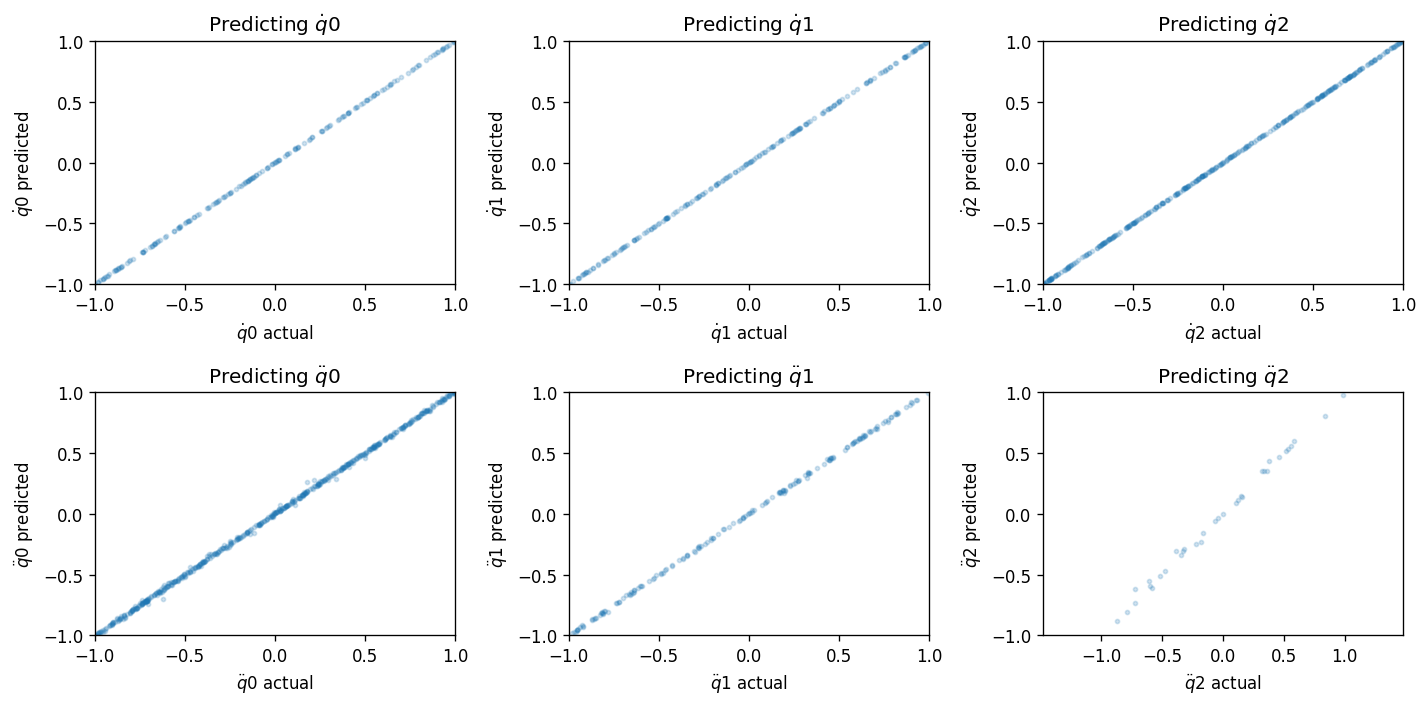

In [9]:
# xt_pred = jax.vmap(partial(equation_of_motion, learned_lagrangian(params)))(x_test, f_test)
# print(f"Min test loss: {min_loss:.6f}")
# xt_pred = jax.vmap(partial(equation_of_motion, learned_lagrangian(params)))(x_test, f_test)
xt_pred = batch_dynamics(params, x_test, f_test)

sampl = xt_pred.shape[0]

k = 0
fig, axes = plt.subplots(2, 3, figsize=(12,6), dpi=120)
for i in range(2):
    for j in range(3):
        axes[i][j].scatter(xt_test[:sampl, k], xt_pred[:sampl, k], s=6, alpha=0.2)
        deriv = r'\dot' if i == 0 else r'\ddot'
        axes[i][j].set_title(fr'Predicting ${deriv} q{j}$')
        axes[i][j].set_xlabel(fr'${deriv} q{j}$ actual')
        axes[i][j].set_ylabel(fr'${deriv} q{j}$ predicted')
        plt.axis('equal')
        k += 1
        axes[i][j].set_xlim(-1, 1)
        axes[i][j].set_ylim(-1, 1)
plt.tight_layout()
plt.show()

# with open('min_loss_model_params.pkl', 'wb') as f:
#     pickle.dump(min_loss_params, f)

In [ ]:
# # choose an initial state
# x1 = np.array([0, 0, 0, 0, 0, 0], dtype=np.float32)
# forcing = np.array([0, 0, 0], dtype=np.float32)

# t2 = np.linspace(0, 1, num=10)
# noise_coeff_3 = 1e-3
# %time x1_model = jax.device_get(solve_lagrangian(learned_lagrangian(params), x1, forcing, t=t2))

In [ ]:
# forcing_res =[]
# # forcing_fn = lambda t: np.array([np.cos(t), 2 * np.sin(t) + 8, np.sin(t)], dtype=np.float32)
# forcing_fn = lambda t: np.array([10 * np.cos(t) , 9.81, 0.1 * np.sin(5*t) ], dtype=np.float32)

# for i in jnp.linspace(0,10, num=1000):
#     forcing = forcing_fn(i)
#     # print(f"fx:{forcing[0]}, fz:{forcing[1]}, ftht:{forcing[2]}")
#     forcing_res.append(forcing)

# forcing_res = np.array(forcing_res)
# forcing_res

# plt.figure(figsize=(10,5))
# plt.plot(forcing_res, linestyle='None', marker='.')
# plt.legend([1,2,3])
# plt.title('Forces')
# plt.xlabel("Time step") ; plt.ylabel("Forces")
# plt.show()

# plt.figure(figsize=(10,5))
# plt.plot(forcing_res/jnp.max(jnp.abs(forcing_res), axis=0), linestyle='None', marker='.')
# plt.legend([1,2,3])
# plt.title('Forces')
# plt.xlabel("Time step") ; plt.ylabel("Forces")
# plt.show()

In [8]:
@jax.jit
def dynamics(params, states, forces):
    states = normalize_dp(states)
    # def single_eom(x, f):
    q, q_t = jnp.split(states, 2)
    f = forces
    L = learned_lagrangian(params)
    # use jacfwd+grad instead of full hessian for a 3×3 mass matrix
    M = jax.jacfwd(jax.grad(L, argnums=1), argnums=1)(q, q_t)
    # M_reg = M
    M_reg = M + 1e-5 * jnp.eye(M.shape[-1])   # add small diagonal
    dLdq = jax.grad(L, argnums=0)(q, q_t)
    C   = jax.jacfwd(jax.jacobian(L, argnums=1), argnums=0)(q, q_t)
    q_tt = jnp.linalg.solve(M_reg, dLdq + f - C @ q_t)
    return jnp.concatenate([q_t, q_tt])

In [9]:
x0 = jnp.array([0,0,0,0,0,0], dtype=np.float32)
tsteps = np.linspace(0, 50, num=5000)

forcing_fn = lambda t: np.array([0.01 * np.cos(0.5*t) , 9.81, 0.01 * np.sin(0.5*t) ], dtype=np.float32)

f = lambda state, t: dynamics(params, state, forcing_fn(t))

xs = []
xts = []
ts = []
frcs = []

for i, tim in enumerate(tsteps):
    xt = f(x0, tim)
    x0 = rk4_step(f, x0, tim, tsteps[1]).copy()
    frc = forcing_fn(tim)
    frcs.append(frc)
    xs.append(x0)
    xts.append(xt)
    ts.append(tim)
    print(f"t={tim:.3f},{i}/{tsteps.shape[0]}", end='\n')

t=0.000,0/5000
t=0.010,1/5000
t=0.020,2/5000
t=0.030,3/5000
t=0.040,4/5000
t=0.050,5/5000
t=0.060,6/5000
t=0.070,7/5000
t=0.080,8/5000
t=0.090,9/5000
t=0.100,10/5000
t=0.110,11/5000
t=0.120,12/5000
t=0.130,13/5000
t=0.140,14/5000
t=0.150,15/5000
t=0.160,16/5000
t=0.170,17/5000
t=0.180,18/5000
t=0.190,19/5000
t=0.200,20/5000
t=0.210,21/5000
t=0.220,22/5000
t=0.230,23/5000
t=0.240,24/5000
t=0.250,25/5000
t=0.260,26/5000
t=0.270,27/5000
t=0.280,28/5000
t=0.290,29/5000
t=0.300,30/5000
t=0.310,31/5000
t=0.320,32/5000
t=0.330,33/5000
t=0.340,34/5000
t=0.350,35/5000
t=0.360,36/5000
t=0.370,37/5000
t=0.380,38/5000
t=0.390,39/5000
t=0.400,40/5000
t=0.410,41/5000
t=0.420,42/5000
t=0.430,43/5000
t=0.440,44/5000
t=0.450,45/5000
t=0.460,46/5000
t=0.470,47/5000
t=0.480,48/5000
t=0.490,49/5000
t=0.500,50/5000
t=0.510,51/5000
t=0.520,52/5000
t=0.530,53/5000
t=0.540,54/5000
t=0.550,55/5000
t=0.560,56/5000
t=0.570,57/5000
t=0.580,58/5000
t=0.590,59/5000
t=0.600,60/5000
t=0.610,61/5000
t=0.620,62/5000
t=

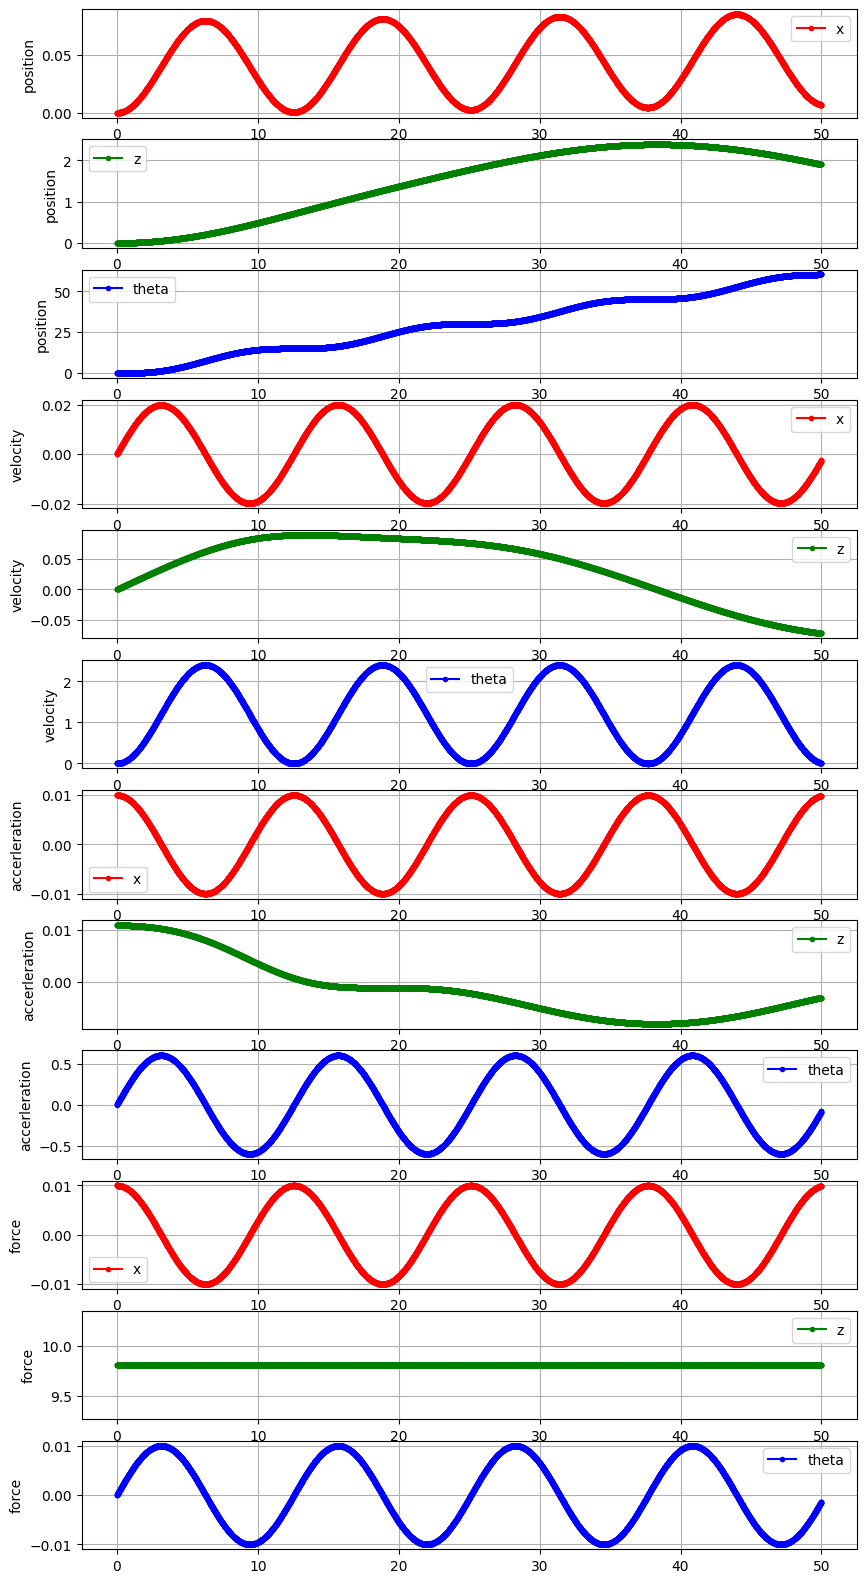

In [10]:
xs = np.array(xs[:])
xts = np.array(xts[:])
frcs = np.array(frcs[:])

cutoff = xs.shape[0] // 1

plt.figure(figsize=(10,20))

legends = ['x', 'z', 'theta']
labels = ['position', 'velocity', 'accerleration', 'force']
colors = ['red', 'green', 'blue']

for i in range(12):
    plt.subplot(12,1,i+1)
    if i < 6:
        plt.plot(ts[:cutoff], xs[:cutoff,i], linestyle='-', marker='.', color=colors[i%3])
    elif i < 9:
        plt.plot(ts[:cutoff], xts[:cutoff,i-3], linestyle='-', marker='.', color=colors[i%3])
    else:
        plt.plot(ts[:cutoff], frcs[:cutoff,i-9], linestyle='-', marker='.', color=colors[i%3])
    plt.legend([legends[i%3]])    
    plt.ylabel(labels[i//3])
    plt.grid()

In [11]:
with open('data/lnn_nof_data_1_1.pkl','wb') as f:
    pickle.dump((ts, xs, xts, frcs), f)